# Batch Inference FirstPass + Tracking per Cyclone

Notebook per:
- lanciare `scripts/predict_firstpass_and_track_from_folder.py` su tutte le cartelle `fromgcloud/<id_ciclone>`;
- usare la soglia per-ciclone dalla **ultima cella** di `moduli/firstpass/notebooks/per_cyclone_threshold_analysis.ipynb`;
- analizzare la distribuzione degli errori di tracking (km);
- visualizzare la traccia GT vs predetta su mappa Mediterraneo.

La cella di esecuzione subprocess usa solo variabili definite nel notebook.


In [1]:
from __future__ import annotations

import ast
import json
import shlex
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


In [2]:
# Risoluzione root repo in modo robusto

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / 'scripts' / 'predict_firstpass_and_track_from_folder.py').exists():
            return p
    raise FileNotFoundError('Repository root non trovato a partire da cwd.')

REPO_ROOT = find_repo_root(Path.cwd())
SCRIPT_PATH = REPO_ROOT / 'scripts' / 'predict_firstpass_and_track_from_folder.py'
THRESH_NOTEBOOK = REPO_ROOT / 'moduli' / 'firstpass' / 'notebooks' / 'per_cyclone_threshold_analysis.ipynb'

print('REPO_ROOT:', REPO_ROOT)
print('SCRIPT_PATH:', SCRIPT_PATH)
print('THRESH_NOTEBOOK:', THRESH_NOTEBOOK)


REPO_ROOT: /media/isacDisk1/Demetra
SCRIPT_PATH: /media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py
THRESH_NOTEBOOK: /media/isacDisk1/Demetra/moduli/firstpass/notebooks/per_cyclone_threshold_analysis.ipynb


In [3]:
# Caricamento soglie dalla ULTIMA cella code non vuota del notebook per-cyclone

def normalize_cyclone_id(v) -> str:
    if pd.isna(v):
        return ''
    s = str(v).strip()
    if not s:
        return ''
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
    except Exception:
        pass
    return s


def extract_thresholds_from_last_cell(nb_path: Path) -> dict[str, float]:
    nb = json.loads(nb_path.read_text())
    code_cells = [
        ''.join(c.get('source', []))
        for c in nb.get('cells', [])
        if c.get('cell_type') == 'code' and ''.join(c.get('source', [])).strip()
    ]
    if not code_cells:
        raise RuntimeError(f'Nessuna cella code non vuota in {nb_path}')

    last_src = code_cells[-1]
    tree = ast.parse(last_src)

    dict_obj = None
    for node in tree.body:
        if isinstance(node, ast.Assign) and isinstance(node.value, ast.Dict):
            try:
                candidate = ast.literal_eval(node.value)
            except Exception:
                continue
            if isinstance(candidate, dict) and candidate:
                dict_obj = candidate

    if not isinstance(dict_obj, dict) or not dict_obj:
        raise RuntimeError(
            'Ultima cella code non contiene un dizionario soglie assegnato. '
            'Controlla per_cyclone_threshold_analysis.ipynb'
        )

    out: dict[str, float] = {}
    for k, v in dict_obj.items():
        kid = normalize_cyclone_id(k)
        if not kid:
            continue
        try:
            out[kid] = float(v)
        except Exception:
            continue

    if not out:
        raise RuntimeError('Dizionario soglie estratto ma vuoto/non valido.')
    return out


THRESHOLDS_BY_ID = extract_thresholds_from_last_cell(THRESH_NOTEBOOK)
print('Soglie caricate:', len(THRESHOLDS_BY_ID))
print('Esempio:', list(THRESHOLDS_BY_ID.items()))


Soglie caricate: 18
Esempio: [('7001702', 0.3), ('7001283', 0.335), ('7001328', 0.515), ('7001358', 0.255), ('7001421', 0.465), ('7001461', 0.19), ('7001466', 0.335), ('7001500', 0.435), ('7001521', 0.395), ('7001542', 0.56), ('7001575', 0.635), ('7001674', 0.43), ('7001715', 0.06), ('7001716', 0.065), ('39299', 0.09), ('82258', 0.125), ('46218', 0.245), ('83565', 0.21)]


In [18]:
# Configurazione batch run (modifica qui)

PYTHON_BIN = sys.executable
FROMGCLOUD_DIR = Path('/media/isacDisk1/fromgcloud')
#OUTPUT_ROOT = Path('/media/isacDisk1/airmassRGB')
OUTPUT_ROOT = Path('/media/isacDisk2/demetra_output/')

FIRSTPASS_MODEL_PATH = REPO_ROOT / 'trained_models' / 'firstpass_model.ckpt'
TRACKING_MODEL_PATH = REPO_ROOT / 'trained_models' / 'checkpoint-tracking-best_1.pth'
MANOS_FILE = REPO_ROOT / 'moduli' / 'videomae' / 'medicane_data_input' / 'medicanes_new_windows.csv'

FIRSTPASS_BATCH_SIZE = 64
FIRSTPASS_NUM_WORKERS = 16


# Se vuoi filtrare un sottoinsieme: ['7001421', '83565']
SELECT_ONLY_IDS = None

# Fallback se un id non ha soglia specifica nel dizionario
DEFAULT_THRESHOLD = 0.50

# Sicurezza: metti True per eseguire davvero
RUN_ENABLED = True

FFMPEG_PATH = '/mnt/share/Demetra_files/VideoMAEv2/ffmpeg-7.0.2-amd64-static/'

print('OUTPUT_ROOT:', OUTPUT_ROOT)


OUTPUT_ROOT: /media/isacDisk2/demetra_output


In [5]:
# Scansione cartelle input e piano esecuzione

if not FROMGCLOUD_DIR.exists():
    raise FileNotFoundError(f'Input root non trovata: {FROMGCLOUD_DIR}')

all_dirs = sorted([p for p in FROMGCLOUD_DIR.iterdir() if p.is_dir()])
plan_rows = []
for d in all_dirs:
    cid = normalize_cyclone_id(d.name)
    if not cid:
        continue
    if SELECT_ONLY_IDS is not None and cid not in {normalize_cyclone_id(x) for x in SELECT_ONLY_IDS}:
        continue
    thr = float(THRESHOLDS_BY_ID.get(cid, DEFAULT_THRESHOLD))
    out_dir = OUTPUT_ROOT / cid
    plan_rows.append({
        'cyclone_id': cid,
        'input_dir': str(d),
        'output_dir': str(out_dir),
        'firstpass_threshold': thr,
        'threshold_source': 'per_cyclone' if cid in THRESHOLDS_BY_ID else 'default',
    })

plan_df = pd.DataFrame(plan_rows).sort_values('cyclone_id').reset_index(drop=True)
print(f'Cyclone folders in piano: {len(plan_df)}')
plan_df.head(20)


Cyclone folders in piano: 20


,cyclone_id,input_dir,output_dir,firstpass_threshold,threshold_source
0,2020,/media/isacDisk1/fromgcloud/2020,/media/isacDisk2/demetra_output/2020,0.500,default
1,2023,/media/isacDisk1/fromgcloud/2023,/media/isacDisk2/demetra_output/2023,0.500,default
2,39299,/media/isacDisk1/fromgcloud/39299,/media/isacDisk2/demetra_output/39299,0.090,per_cyclone
3,46218,/media/isacDisk1/fromgcloud/46218,/media/isacDisk2/demetra_output/46218,0.245,per_cyclone
4,7001283,/media/isacDisk1/fromgcloud/7001283,/media/isacDisk2/demetra_output/7001283,0.335,per_cyclone
5,7001328,/media/isacDisk1/fromgcloud/7001328,/media/isacDisk2/demetra_output/7001328,0.515,per_cyclone
6,7001358,/media/isacDisk1/fromgcloud/7001358,/media/isacDisk2/demetra_output/7001358,0.255,per_cyclone
7,7001421,/media/isacDisk1/fromgcloud/7001421,/media/isacDisk2/demetra_output/7001421,0.465,per_cyclone
8,7001461,/media/isacDisk1/fromgcloud/7001461,/media/isacDisk2/demetra_output/7001461,0.190,per_cyclone
9,7001466,/media/isacDisk1/fromgcloud/7001466,/media/isacDisk2/demetra_output/7001466,0.335,per_cyclone


In [15]:
plan_df.loc[plan_df.cyclone_id == '2020', 'firstpass_threshold'] = round(np.mean(list(THRESHOLDS_BY_ID.values())), 3)

In [6]:
plan_df = plan_df[2:]
plan_df

,cyclone_id,input_dir,output_dir,firstpass_threshold,threshold_source
2,39299,/media/isacDisk1/fromgcloud/39299,/media/isacDisk2/demetra_output/39299,0.090,per_cyclone
3,46218,/media/isacDisk1/fromgcloud/46218,/media/isacDisk2/demetra_output/46218,0.245,per_cyclone
4,7001283,/media/isacDisk1/fromgcloud/7001283,/media/isacDisk2/demetra_output/7001283,0.335,per_cyclone
5,7001328,/media/isacDisk1/fromgcloud/7001328,/media/isacDisk2/demetra_output/7001328,0.515,per_cyclone
6,7001358,/media/isacDisk1/fromgcloud/7001358,/media/isacDisk2/demetra_output/7001358,0.255,per_cyclone
7,7001421,/media/isacDisk1/fromgcloud/7001421,/media/isacDisk2/demetra_output/7001421,0.465,per_cyclone
8,7001461,/media/isacDisk1/fromgcloud/7001461,/media/isacDisk2/demetra_output/7001461,0.190,per_cyclone
9,7001466,/media/isacDisk1/fromgcloud/7001466,/media/isacDisk2/demetra_output/7001466,0.335,per_cyclone
10,7001500,/media/isacDisk1/fromgcloud/7001500,/media/isacDisk2/demetra_output/7001500,0.435,per_cyclone
11,7001521,/media/isacDisk1/fromgcloud/7001521,/media/isacDisk2/demetra_output/7001521,0.395,per_cyclone


In [76]:
# Esecuzione batch via subprocess

def build_cmd(row: pd.Series) -> list[str]:
    cmd = [
        str(PYTHON_BIN),
        str(SCRIPT_PATH),
        '--input_dir', str(row['input_dir']),
        '--output_dir', str(row['output_dir']),
        '--firstpass_model_path', str(FIRSTPASS_MODEL_PATH),
        '--tracking_model_path', str(TRACKING_MODEL_PATH),
        '--firstpass_threshold', f"{float(row['firstpass_threshold']):.3f}",
        '--manos_file', str(MANOS_FILE),
        '--firstpass_batch_size', str(int(FIRSTPASS_BATCH_SIZE)),
        '--firstpass_num_workers', str(int(FIRSTPASS_NUM_WORKERS)),
        '--standard_tiling',
        '--make_video',
        '--ffmpeg_path', str(FFMPEG_PATH),
    ]
    return cmd

run_rows = []
if not RUN_ENABLED:
    print('RUN_ENABLED=False: nessun subprocess lanciato. Metti RUN_ENABLED=True e rilancia questa cella.')
else:
    for _, row in plan_df.iterrows():
        cmd = build_cmd(row)
        print('\n' + '=' * 100)
        print(f"Cyclone {row['cyclone_id']} | threshold={row['firstpass_threshold']:.3f} ({row['threshold_source']})")
        print(shlex.join(cmd))

        t0 = time.time()
        proc = subprocess.run(cmd, cwd=str(REPO_ROOT), text=True)
        dt = time.time() - t0

        run_rows.append({
            'cyclone_id': row['cyclone_id'],
            'return_code': int(proc.returncode),
            'elapsed_sec': round(dt, 2),
            'output_dir': row['output_dir'],
            'threshold': float(row['firstpass_threshold']),
        })

run_df = pd.DataFrame(run_rows)
if not run_df.empty:
    display(run_df)
    print('Fail count:', int((run_df['return_code'] != 0).sum()))
else:
    print('Nessun run eseguito.')
    



Cyclone 39299 | threshold=0.090 (per_cyclone)
/home/isac/miniconda3/envs/videomae/bin/python /media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py --input_dir /media/isacDisk1/fromgcloud/39299 --output_dir /media/isacDisk2/demetra_output/39299 --firstpass_model_path /media/isacDisk1/Demetra/trained_models/firstpass_model.ckpt --tracking_model_path /media/isacDisk1/Demetra/trained_models/checkpoint-tracking-best_1.pth --firstpass_threshold 0.090 --manos_file /media/isacDisk1/Demetra/moduli/videomae/medicane_data_input/medicanes_new_windows.csv --firstpass_batch_size 64 --firstpass_num_workers 16 --standard_tiling --make_video --ffmpeg_path /mnt/share/Demetra_files/VideoMAEv2/ffmpeg-7.0.2-amd64-static/
Impossibile caricare la libreria torch dynamo
[INFO] CSV finale gia presente: /media/isacDisk2/demetra_output/39299/tracking_inference_predictions.csv. Salto inferenze.
[INFO] Frames raccolti: 1212 (2021-10-27 09:20:00 -> 2021-10-31 14:15:00)
[INFO] GT points caricat

Traceback (most recent call last):
  File "/media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py", line 1560, in <module>
    main()
  File "/media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py", line 1411, in main
    video_path = _make_firstpass_roi_video(
  File "/media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py", line 1345, in _make_firstpass_roi_video
    n_frames = _render_firstpass_roi_frames(
  File "/media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py", line 1281, in _render_firstpass_roi_frames
    if cv2.imwrite(str(out_png), img):
KeyboardInterrupt


KeyboardInterrupt: 

In [77]:
# Raccolta CSV tracking tile-level dai run (utile per metriche err_px / err_km)

if 'run_df' in globals() and not run_df.empty:
    source_df = run_df.copy()
else:
    source_df = plan_df.copy()

rows = []
for _, r in source_df.iterrows():
    cid = normalize_cyclone_id(r['cyclone_id'])
    out_dir = Path(r['output_dir'])
    csv_path = out_dir / '_tmp_tracking_inference_predictions_tiles.csv'
    if not csv_path.exists():
        continue
    try:
        df = pd.read_csv(csv_path)
    except Exception as exc:
        print(f'[WARN] Impossibile leggere {csv_path}: {exc}')
        continue
    df['cyclone_id'] = cid
    df['output_dir'] = str(out_dir)
    rows.append(df)

if rows:
    all_tile_preds = pd.concat(rows, ignore_index=True)
else:
    all_tile_preds = pd.DataFrame()

print('Rows tile predictions:', len(all_tile_preds))
if not all_tile_preds.empty:
    if 'has_target' in all_tile_preds.columns:
        print('has_target counts:', all_tile_preds['has_target'].value_counts(dropna=False).to_dict())
    display(all_tile_preds.head(10))


Rows tile predictions: 4380
has_target counts: {0: 4171, 1: 209}


,path,has_target,pred_x,pred_y,target_x,target_y,err_px,err_km,tile_offset_x,tile_offset_y,pred_x_global,pred_y_global,pred_lat,pred_lon,cyclone_id,output_dir,target_x_global,target_y_global,target_lat,target_lon
0,27-10-2021_1035_426_196,0,91,46,NaN,NaN,NaN,NaN,426.0,196.0,517,242,36.08,9.83,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
1,27-10-2021_1050_426_196,0,100,57,NaN,NaN,NaN,NaN,426.0,196.0,526,253,35.66,10.14,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
2,27-10-2021_1105_426_196,0,104,49,NaN,NaN,NaN,NaN,426.0,196.0,530,245,35.96,10.28,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
3,27-10-2021_1120_426_196,0,92,35,NaN,NaN,NaN,NaN,426.0,196.0,518,231,36.49,9.87,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
4,27-10-2021_1135_426_196,0,96,54,NaN,NaN,NaN,NaN,426.0,196.0,522,250,35.77,10.00,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
5,27-10-2021_1150_426_196,0,86,45,NaN,NaN,NaN,NaN,426.0,196.0,512,241,36.11,9.66,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
6,27-10-2021_1205_426_196,0,79,34,NaN,NaN,NaN,NaN,426.0,196.0,505,230,36.53,9.42,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
7,27-10-2021_1220_426_196,0,86,48,NaN,NaN,NaN,NaN,426.0,196.0,512,244,36.00,9.66,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
8,27-10-2021_1235_426_196,0,91,58,NaN,NaN,NaN,NaN,426.0,196.0,517,254,35.62,9.83,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN
9,27-10-2021_1250_426_196,0,91,55,NaN,NaN,NaN,NaN,426.0,196.0,517,251,35.74,9.83,39299,/media/isacDisk2/demetra_output/39299,NaN,NaN,NaN,NaN


ERA5 rows mapped to non-700 IDs: 638 | IDs: ['39299', '46218', '82258', '83565']
Saved nearest-hour eval: /media/isacDisk1/Demetra/notebooks/batch_outputs/tracking_error_nearest_hour_eval.csv | rows: 1158
Rows with GT match + err_km_eval>0: 1076
Cyclones with valid rows: 18
Rows in good window: 923 | outside: 153


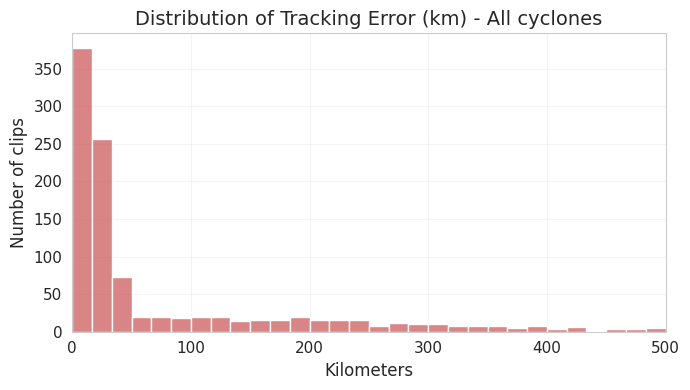

Saved: /media/isacDisk1/Demetra/notebooks/batch_outputs/tracking_error_distribution_all_cyclones.png
Median err_km (all): 23.906616593985532
Mean err_km (all): 120.33449931588964
Saved: /media/isacDisk1/Demetra/notebooks/batch_outputs/tracking_error_distribution_all_cyclones_mature_split.png
Istogrammi per-ciclone salvati: 18


,cyclone_id,n_total,n_in_good_window,n_outside_good_window,median_err_km_total,mean_err_km_total,median_err_km_in,median_err_km_out,hist_path
0,39299,76,51,25,37.564819,234.359405,21.296976,620.914352,/media/isacDisk1/Demetra/notebooks/batch_outpu...
1,46218,122,115,7,23.220694,79.579025,22.115382,203.211437,/media/isacDisk1/Demetra/notebooks/batch_outpu...
2,7001283,29,25,4,33.852601,78.642235,25.906702,199.322615,/media/isacDisk1/Demetra/notebooks/batch_outpu...
3,7001328,57,57,0,13.695145,31.778080,13.695145,NaN,/media/isacDisk1/Demetra/notebooks/batch_outpu...
4,7001358,40,40,0,29.990520,92.567704,29.990520,NaN,/media/isacDisk1/Demetra/notebooks/batch_outpu...
5,7001421,33,33,0,16.070740,34.261596,16.070740,NaN,/media/isacDisk1/Demetra/notebooks/batch_outpu...
6,7001461,44,38,6,35.565184,117.790518,20.238499,146.951993,/media/isacDisk1/Demetra/notebooks/batch_outpu...
7,7001466,74,72,2,16.896092,77.433950,16.668552,201.042593,/media/isacDisk1/Demetra/notebooks/batch_outpu...
8,7001500,22,22,0,34.762986,53.194666,34.762986,NaN,/media/isacDisk1/Demetra/notebooks/batch_outpu...
9,7001521,40,33,7,29.940347,53.162408,22.624102,164.252817,/media/isacDisk1/Demetra/notebooks/batch_outpu...


In [83]:
# ### Distribuzione degli errori (nearest-hour verso GT, no interpolazione)
# Costruisce un dataframe temporaneo scegliendo, per ogni ciclone e ora, la tile piu' vicina a HH:00.
# Poi calcola err_km contro GT (MANOS_FILE) all'ora corrispondente.

BATCH_OUT_DIR = REPO_ROOT / 'notebooks' / 'batch_outputs'
HIST_OUT_DIR = BATCH_OUT_DIR / 'hist_per_cyclone'
TMP_ERR_NEAREST_CSV = BATCH_OUT_DIR / 'tracking_error_nearest_hour_eval.csv'
HIST_XMAX_KM = 500.0
HIST_BINS = 30
BATCH_OUT_DIR.mkdir(parents=True, exist_ok=True)
HIST_OUT_DIR.mkdir(parents=True, exist_ok=True)

if all_tile_preds.empty:
    print('all_tile_preds vuoto: nessun istogramma.')
else:
    eval_src = all_tile_preds.copy()

    if 'path' not in eval_src.columns:
        raise RuntimeError("all_tile_preds non contiene colonna 'path'.")

    # Parse datetime dalla folder tile: DD-MM-YYYY_HHMM_... 
    path_base = eval_src['path'].astype(str).str.replace(r'.*[\/]', '', regex=True)
    dt_str = path_base.str.extract(r'^(\d{2}-\d{2}-\d{4}_\d{4})', expand=False)
    eval_src['tile_dt'] = pd.to_datetime(dt_str, format='%d-%m-%Y_%H%M', errors='coerce')
    eval_src = eval_src[eval_src['tile_dt'].notna()].copy()

    if eval_src.empty:
        print('Nessuna data valida trovata in path tile.')
    else:
        eval_src['cyclone_id'] = eval_src['cyclone_id'].apply(normalize_cyclone_id)
        eval_src = eval_src[eval_src['cyclone_id'] != ''].copy()

        # Nearest-hour selection: 1 riga per (cyclone_id, ora)
        eval_src['hour_key'] = eval_src['tile_dt'].dt.round('h')
        eval_src['dist_to_hour_sec'] = (eval_src['tile_dt'] - eval_src['hour_key']).abs().dt.total_seconds()
        eval_src = (
            eval_src
            .sort_values(['cyclone_id', 'hour_key', 'dist_to_hour_sec', 'tile_dt'])
            .drop_duplicates(subset=['cyclone_id', 'hour_key'], keep='first')
            .reset_index(drop=True)
        )

        # GT source (medicanes + CL7 extra)
        # - finestra buona: da MANOS_FILE
        # - matching GT orario (anche fuori finestra): MANOS_FILE + manos_CL7_pixel.csv
        gt_main = pd.read_csv(MANOS_FILE)
        if 'id_cyc_unico' not in gt_main.columns:
            raise RuntimeError(f"MANOS_FILE senza id_cyc_unico: {MANOS_FILE}")

        gt_main['cyclone_id'] = gt_main['id_cyc_unico'].apply(normalize_cyclone_id)
        gt_main['id_final_norm'] = gt_main['id_final'].apply(normalize_cyclone_id) if 'id_final' in gt_main.columns else ''
        gt_main['idorig_norm'] = gt_main['idorig'].apply(normalize_cyclone_id) if 'idorig' in gt_main.columns else ''
        gt_main['time'] = pd.to_datetime(gt_main.get('time'), errors='coerce')
        gt_main['lat'] = pd.to_numeric(gt_main.get('lat'), errors='coerce')
        gt_main['lon'] = pd.to_numeric(gt_main.get('lon'), errors='coerce')
        if 'start_time' in gt_main.columns:
            gt_main['start_time'] = pd.to_datetime(gt_main.get('start_time'), errors='coerce')
        else:
            gt_main['start_time'] = pd.NaT
        if 'end_time' in gt_main.columns:
            gt_main['end_time'] = pd.to_datetime(gt_main.get('end_time'), errors='coerce')
        else:
            gt_main['end_time'] = pd.NaT
        id_any_main = (
            gt_main['cyclone_id'].astype(str).ne('')
            | gt_main['id_final_norm'].astype(str).ne('')
            | gt_main['idorig_norm'].astype(str).ne('')
        )
        gt_main = gt_main[
            gt_main['time'].notna() & gt_main['lat'].notna() & gt_main['lon'].notna() & id_any_main
        ].copy()

        manos_cl7_file = REPO_ROOT / 'notebooks' / 'manos_CL7_pixel.csv'
        if manos_cl7_file.exists():
            gt_cl7 = pd.read_csv(manos_cl7_file)
            if 'id_cyc_unico' in gt_cl7.columns:
                gt_cl7['cyclone_id'] = gt_cl7['id_cyc_unico'].apply(normalize_cyclone_id)
            else:
                gt_cl7['cyclone_id'] = ''
            gt_cl7['id_final_norm'] = gt_cl7['id_final'].apply(normalize_cyclone_id) if 'id_final' in gt_cl7.columns else ''
            gt_cl7['idorig_norm'] = gt_cl7['idorig'].apply(normalize_cyclone_id) if 'idorig' in gt_cl7.columns else ''
            gt_cl7['time'] = pd.to_datetime(gt_cl7.get('time'), errors='coerce')
            gt_cl7['lat'] = pd.to_numeric(gt_cl7.get('lat'), errors='coerce')
            gt_cl7['lon'] = pd.to_numeric(gt_cl7.get('lon'), errors='coerce')
            gt_cl7['start_time'] = pd.NaT
            gt_cl7['end_time'] = pd.NaT
            gt_cl7 = gt_cl7[
                gt_cl7['time'].notna() & gt_cl7['lat'].notna() & gt_cl7['lon'].notna() & (gt_cl7['cyclone_id'] != '')
            ].copy()
        else:
            gt_cl7 = pd.DataFrame(columns=['cyclone_id', 'id_final_norm', 'idorig_norm', 'time', 'lat', 'lon', 'start_time', 'end_time'])

        # ERA5 GT for non-700 cyclones: map ERA5 names to id_final from medicanes_new_windows.
        era5_file = REPO_ROOT / 'moduli' / 'videomae' / 'medicane_data_input' / 'era5_medicanes.csv'
        if era5_file.exists():
            gt_era5 = pd.read_csv(era5_file)
            gt_era5['time'] = pd.to_datetime(gt_era5.get('time'), errors='coerce')
            gt_era5['start_time'] = pd.to_datetime(gt_era5.get('start_time'), errors='coerce')
            gt_era5['end_time'] = pd.to_datetime(gt_era5.get('end_time'), errors='coerce')
            gt_era5['lat'] = pd.to_numeric(gt_era5.get('lat'), errors='coerce')
            gt_era5['lon'] = pd.to_numeric(gt_era5.get('lon'), errors='coerce')
            gt_era5['name_norm'] = gt_era5.get('name', '').astype(str).str.strip().str.lower()
            gt_era5 = gt_era5[
                gt_era5['time'].notna() & gt_era5['lat'].notna() & gt_era5['lon'].notna() & (gt_era5['name_norm'] != '')
            ].copy()

            name_to_id = {}
            id_to_name = {}
            if 'name' in gt_main.columns:
                map_df = gt_main.copy()
                map_df['name_norm'] = map_df['name'].astype(str).str.strip().str.lower()
                map_df['name_orig'] = map_df['name'].astype(str).str.strip()
                map_df = map_df[
                    map_df['name_norm'].notna()
                    & (map_df['name_norm'] != '')
                    & map_df['id_final_norm'].notna()
                    & (map_df['id_final_norm'] != '')
                    & (~map_df['id_final_norm'].astype(str).str.startswith('700'))
                ].copy()
                for n, g in map_df.groupby('name_norm'):
                    ids = sorted(set(g['id_final_norm'].astype(str)))
                    if len(ids) == 1:
                        name_to_id[n] = ids[0]
                        names = [x for x in g['name_orig'].astype(str).tolist() if x]
                        if names:
                            id_to_name[ids[0]] = names[0]

            gt_era5['cyclone_id'] = gt_era5['name_norm'].map(name_to_id).fillna('')
            gt_era5['id_final_norm'] = gt_era5['cyclone_id']
            gt_era5['idorig_norm'] = ''
            gt_era5 = gt_era5[gt_era5['cyclone_id'] != ''].copy()
        else:
            gt_era5 = pd.DataFrame(columns=['cyclone_id', 'id_final_norm', 'idorig_norm', 'time', 'lat', 'lon', 'start_time', 'end_time'])
            id_to_name = {}

        if 'id_to_name' not in locals():
            id_to_name = {}

        gt_cols = ['cyclone_id', 'id_final_norm', 'idorig_norm', 'time', 'lat', 'lon', 'start_time', 'end_time']
        gt_match_df = pd.concat([
            gt_main[gt_cols] if not gt_main.empty else pd.DataFrame(columns=gt_cols),
            gt_cl7[gt_cols] if not gt_cl7.empty else pd.DataFrame(columns=gt_cols),
            gt_era5[gt_cols] if not gt_era5.empty else pd.DataFrame(columns=gt_cols),
        ], ignore_index=True)
        if not gt_match_df.empty:
            gt_match_df = gt_match_df.drop_duplicates(subset=['cyclone_id', 'id_final_norm', 'idorig_norm', 'time', 'lat', 'lon'], keep='first')
        if 'gt_era5' in locals() and isinstance(gt_era5, pd.DataFrame) and (not gt_era5.empty):
            print('ERA5 rows mapped to non-700 IDs:', len(gt_era5), '| IDs:', sorted(gt_era5['cyclone_id'].astype(str).unique().tolist()))
        gt_match_df['hour_key'] = pd.to_datetime(gt_match_df.get('time'), errors='coerce').dt.round('h')
        gt_main['hour_key'] = pd.to_datetime(gt_main.get('time'), errors='coerce').dt.round('h')

        def _build_aliases_local(cyclone_id: str) -> set:
            cid = normalize_cyclone_id(cyclone_id)
            aliases = {cid} if cid else set()
            if cid and cid.isdigit():
                if cid.startswith('700') and len(cid) > 3:
                    aliases.add(cid[3:])
                else:
                    aliases.add('700' + cid)
            return {a for a in aliases if a}

        # Pre-index GT for error matching by (alias, hour_key), using main + CL7 extra.
        gt_index = {}
        for row in gt_match_df.itertuples(index=False):
            keys = []
            for c in ['cyclone_id', 'id_final_norm', 'idorig_norm']:
                v = getattr(row, c, '')
                if isinstance(v, str) and v != '':
                    keys.append(v)
            keys = list(set(keys))
            for k in keys:
                gt_index.setdefault((k, pd.Timestamp(row.hour_key)), []).append((float(row.lat), float(row.lon)))

        # Good-window cache comes from main MANOS only.
        alias_good_window = {}
        alias_time_window_main = {}
        for row in gt_main.itertuples(index=False):
            keys = []
            for c in ['cyclone_id', 'id_final_norm', 'idorig_norm']:
                v = getattr(row, c, '')
                if isinstance(v, str) and v != '':
                    keys.append(v)
            keys = list(set(keys))

            row_time = pd.Timestamp(getattr(row, 'time'))
            st = getattr(row, 'start_time', pd.NaT)
            en = getattr(row, 'end_time', pd.NaT)
            st = pd.Timestamp(st) if pd.notna(st) else pd.NaT
            en = pd.Timestamp(en) if pd.notna(en) else pd.NaT
            if pd.isna(st):
                st = row_time
            if pd.isna(en):
                en = row_time
            if en < st:
                st, en = en, st

            for k in keys:
                if k in alias_good_window:
                    cur_st, cur_en = alias_good_window[k]
                    alias_good_window[k] = (min(cur_st, st), max(cur_en, en))
                else:
                    alias_good_window[k] = (st, en)

                if k in alias_time_window_main:
                    cur_st, cur_en = alias_time_window_main[k]
                    alias_time_window_main[k] = (min(cur_st, row_time), max(cur_en, row_time))
                else:
                    alias_time_window_main[k] = (row_time, row_time)

        # Fallback time-window from match dataframe (main+CL7) only if no main window exists.
        alias_time_window_match = {}
        for row in gt_match_df.itertuples(index=False):
            keys = []
            for c in ['cyclone_id', 'id_final_norm', 'idorig_norm']:
                v = getattr(row, c, '')
                if isinstance(v, str) and v != '':
                    keys.append(v)
            keys = list(set(keys))
            row_time = pd.Timestamp(getattr(row, 'time'))
            for k in keys:
                if k in alias_time_window_match:
                    cur_st, cur_en = alias_time_window_match[k]
                    alias_time_window_match[k] = (min(cur_st, row_time), max(cur_en, row_time))
                else:
                    alias_time_window_match[k] = (row_time, row_time)

        # Cache good window per cyclone id (using aliases)
        cid_good_window_cache = {}
        for cid in sorted(eval_src['cyclone_id'].dropna().astype(str).unique()):
            aliases = _build_aliases_local(cid)
            starts = []
            ends = []
            for a in aliases:
                if a in alias_good_window:
                    w = alias_good_window[a]
                    starts.append(pd.Timestamp(w[0]))
                    ends.append(pd.Timestamp(w[1]))
            if not starts:
                for a in aliases:
                    if a in alias_time_window_main:
                        w = alias_time_window_main[a]
                        starts.append(pd.Timestamp(w[0]))
                        ends.append(pd.Timestamp(w[1]))
            if not starts:
                for a in aliases:
                    if a in alias_time_window_match:
                        w = alias_time_window_match[a]
                        starts.append(pd.Timestamp(w[0]))
                        ends.append(pd.Timestamp(w[1]))
            if starts:
                cid_good_window_cache[cid] = (min(starts), max(ends))
            else:
                cid_good_window_cache[cid] = (pd.NaT, pd.NaT)

        # Haversine local
        def _haversine_km(lat1, lon1, lat2, lon2):
            r = 6371.0088
            lat1 = np.radians(float(lat1))
            lon1 = np.radians(float(lon1))
            lat2 = np.radians(np.asarray(lat2, dtype=float))
            lon2 = np.radians(np.asarray(lon2, dtype=float))
            dlat = lat2 - lat1
            dlon = lon2 - lon1
            a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dlon / 2.0) ** 2)
            return 2.0 * r * np.arcsin(np.sqrt(a))

        rows_eval = []
        for row in eval_src.itertuples(index=False):
            cid = normalize_cyclone_id(getattr(row, 'cyclone_id', ''))
            hk = pd.Timestamp(getattr(row, 'hour_key'))
            pred_lat = pd.to_numeric(getattr(row, 'pred_lat', np.nan), errors='coerce')
            pred_lon = pd.to_numeric(getattr(row, 'pred_lon', np.nan), errors='coerce')

            gw_st, gw_en = cid_good_window_cache.get(cid, (pd.NaT, pd.NaT))
            in_good_window = int(pd.notna(gw_st) and pd.notna(gw_en) and (hk >= gw_st) and (hk <= gw_en))

            out = {
                'cyclone_id': cid,
                'path': getattr(row, 'path', ''),
                'tile_dt': getattr(row, 'tile_dt', pd.NaT),
                'hour_key': hk,
                'dist_to_hour_sec': float(getattr(row, 'dist_to_hour_sec', np.nan)),
                'pred_lat': pred_lat,
                'pred_lon': pred_lon,
                'gt_lat': np.nan,
                'gt_lon': np.nan,
                'err_km_eval': np.nan,
                'has_gt_match': 0,
                'in_good_window': in_good_window,
                'good_window_start': gw_st,
                'good_window_end': gw_en,
                'orig_has_target': pd.to_numeric(getattr(row, 'has_target', np.nan), errors='coerce'),
                'orig_err_km': pd.to_numeric(getattr(row, 'err_km', np.nan), errors='coerce'),
            }

            if np.isfinite(pred_lat) and np.isfinite(pred_lon):
                aliases = _build_aliases_local(cid)
                cand = []
                for a in aliases:
                    cand.extend(gt_index.get((a, hk), []))

                if len(cand) > 0:
                    arr = np.asarray(cand, dtype=float)
                    d = _haversine_km(pred_lat, pred_lon, arr[:, 0], arr[:, 1])
                    i = int(np.argmin(d))
                    out['gt_lat'] = float(arr[i, 0])
                    out['gt_lon'] = float(arr[i, 1])
                    out['err_km_eval'] = float(d[i])
                    out['has_gt_match'] = 1

            rows_eval.append(out)

        err_eval_df = pd.DataFrame(rows_eval)
        err_eval_df.to_csv(TMP_ERR_NEAREST_CSV, index=False)
        print('Saved nearest-hour eval:', TMP_ERR_NEAREST_CSV, '| rows:', len(err_eval_df))

        err_df = err_eval_df[
            err_eval_df['err_km_eval'].notna() & (pd.to_numeric(err_eval_df['err_km_eval'], errors='coerce') > 0)
        ].copy()

        print('Rows with GT match + err_km_eval>0:', len(err_df))
        print('Cyclones with valid rows:', int(err_df['cyclone_id'].nunique()) if not err_df.empty else 0)
        if not err_df.empty and 'in_good_window' in err_df.columns:
            in_n = int((pd.to_numeric(err_df['in_good_window'], errors='coerce') == 1).sum())
            out_n = int((pd.to_numeric(err_df['in_good_window'], errors='coerce') != 1).sum())
            print('Rows in good window:', in_n, '| outside:', out_n)

        if err_df.empty:
            print('Nessun errore valido da plottare.')
        else:
            # Istogramma globale
            fig, ax = plt.subplots(figsize=(7, 4), tight_layout=True)
            sns.histplot(err_df['err_km_eval'], bins=HIST_BINS, binrange=(0, HIST_XMAX_KM), ax=ax, color='indianred')
            ax.set_title('Distribution of Tracking Error (km) - All cyclones', fontsize=14)
            ax.set_xlabel('Kilometers', fontsize=12)
            ax.set_ylabel('Number of clips', fontsize=12)
            ax.tick_params(axis='both', labelsize=11)
            ax.grid(alpha=0.2)
            ax.set_xlim(0, HIST_XMAX_KM)
            global_png = BATCH_OUT_DIR / 'tracking_error_distribution_all_cyclones.png'
            fig.savefig(global_png, dpi=150)
            plt.show()
            plt.close(fig)
            print('Saved:', global_png)
            print('Median err_km (all):', float(np.median(err_df['err_km_eval'])))
            print('Mean err_km (all):', float(np.mean(err_df['err_km_eval'])))

            # Istogramma globale split inside/outside mature phase
            if 'in_good_window' in err_df.columns:
                in_mask_all = pd.to_numeric(err_df['in_good_window'], errors='coerce').fillna(0).astype(int) == 1
                vals_in_all = pd.to_numeric(err_df.loc[in_mask_all, 'err_km_eval'], errors='coerce').dropna()
                vals_out_all = pd.to_numeric(err_df.loc[~in_mask_all, 'err_km_eval'], errors='coerce').dropna()
                vals_in_all = vals_in_all[vals_in_all > 0]
                vals_out_all = vals_out_all[vals_out_all > 0]

                if (not vals_in_all.empty) or (not vals_out_all.empty):
                    fig, ax = plt.subplots(figsize=(7, 4), tight_layout=True)
                    if not vals_out_all.empty:
                        sns.histplot(
                            vals_out_all,
                            bins=HIST_BINS,
                            binrange=(0, HIST_XMAX_KM),
                            ax=ax,
                            color='mediumpurple',
                            alpha=0.45,
                            label=f'Outside mature phase (n={len(vals_out_all)})',
                        )
                    if not vals_in_all.empty:
                        sns.histplot(
                            vals_in_all,
                            bins=HIST_BINS,
                            binrange=(0, HIST_XMAX_KM),
                            ax=ax,
                            color='indianred',
                            alpha=0.55,
                            label=f'Inside mature phase (n={len(vals_in_all)})',
                        )

                    ax.set_title('Distribution of Tracking Error (km) - All cyclones', fontsize=13)
                    ax.set_xlabel('Kilometers', fontsize=11)
                    ax.set_ylabel('Number of clips', fontsize=11)
                    ax.grid(alpha=0.2)
                    ax.set_xlim(0, HIST_XMAX_KM)
                    if (not vals_out_all.empty) and (not vals_in_all.empty):
                        ax.legend(fontsize=8)

                    global_split_png = BATCH_OUT_DIR / 'tracking_error_distribution_all_cyclones_mature_split.png'
                    fig.savefig(global_split_png, dpi=150)
                    plt.close(fig)
                    print('Saved:', global_split_png)

            # Istogrammi per cyclone_id (dentro/fuori finestra buona nello stesso grafico)
            hist_rows = []
            for cid, g in err_df.groupby('cyclone_id'):
                cid = normalize_cyclone_id(cid)
                if not cid:
                    continue

                vals = pd.to_numeric(g['err_km_eval'], errors='coerce')
                vals = vals[vals.notna() & (vals > 0)]
                if vals.empty:
                    continue

                g2 = g.loc[vals.index].copy()
                in_mask = pd.to_numeric(g2.get('in_good_window', 0), errors='coerce').fillna(0).astype(int) == 1

                vals_in = pd.to_numeric(g2.loc[in_mask, 'err_km_eval'], errors='coerce').dropna()
                vals_out = pd.to_numeric(g2.loc[~in_mask, 'err_km_eval'], errors='coerce').dropna()
                vals_in = vals_in[vals_in > 0]
                vals_out = vals_out[vals_out > 0]

                if vals_in.empty and vals_out.empty:
                    continue

                all_vals = pd.concat([vals_in, vals_out], ignore_index=True)

                fig, ax = plt.subplots(figsize=(7, 4), tight_layout=True)
                if not vals_out.empty:
                    sns.histplot(
                        vals_out,
                        bins=HIST_BINS,
                        binrange=(0, HIST_XMAX_KM),
                        ax=ax,
                        color='mediumpurple',
                        alpha=0.45,
                        label=f'Outside mature phase (n={len(vals_out)})',
                    )
                if not vals_in.empty:
                    sns.histplot(
                        vals_in,
                        bins=HIST_BINS,
                        binrange=(0, HIST_XMAX_KM),
                        ax=ax,
                        color='indianred',
                        alpha=0.55,
                        label=f'Inside mature phase (n={len(vals_in)})',
                    )

                if cid.startswith('700') and len(cid) > 3:
                    cid_plot = cid[3:]
                else:
                    cid_plot = id_to_name.get(cid, cid)
                ax.set_title(f'Distribution of Tracking Error (km) - Cyclone {cid_plot}', fontsize=13)
                ax.set_xlabel('Kilometers', fontsize=11)
                ax.set_ylabel('Number of clips', fontsize=11)
                ax.grid(alpha=0.2)
                ax.set_xlim(0, HIST_XMAX_KM)
                if (not vals_out.empty) and (not vals_in.empty):
                    ax.legend(fontsize=8)

                out_png = HIST_OUT_DIR / f'tracking_error_distribution_{cid}.png'
                fig.savefig(out_png, dpi=150)
                plt.close(fig)

                hist_rows.append({
                    'cyclone_id': cid,
                    'n_total': int(len(all_vals)),
                    'n_in_good_window': int(len(vals_in)),
                    'n_outside_good_window': int(len(vals_out)),
                    'median_err_km_total': float(np.median(all_vals)),
                    'mean_err_km_total': float(np.mean(all_vals)),
                    'median_err_km_in': float(np.median(vals_in)) if not vals_in.empty else np.nan,
                    'median_err_km_out': float(np.median(vals_out)) if not vals_out.empty else np.nan,
                    'hist_path': str(out_png),
                })

            hist_summary_df = pd.DataFrame(hist_rows).sort_values('cyclone_id').reset_index(drop=True)
            print('Istogrammi per-ciclone salvati:', len(hist_summary_df))
            if not hist_summary_df.empty:
                display(hist_summary_df.head(30))













### Mappe

In [55]:
# Configurazione mappe Mediterraneo per TUTTI i cicloni del piano
# + helper unificati per plotting mappe/tracce (riusati anche nella sezione CL7)

if 'create_basemap_obj' not in globals():
    VIDEOMAE_DIR = REPO_ROOT / 'moduli' / 'videomae'
    if str(VIDEOMAE_DIR) not in sys.path:
        sys.path.insert(0, str(VIDEOMAE_DIR))
    from medicane_utils.geo_const import latcorners, loncorners, create_basemap_obj

from mpl_toolkits.basemap import Basemap
from matplotlib.lines import Line2D


def _nearest_to_hour(df: pd.DataFrame, time_col: str) -> pd.DataFrame:
    work = df.copy()
    work[time_col] = pd.to_datetime(work[time_col], errors='coerce')
    work = work[work[time_col].notna()].copy()
    if work.empty:
        return work
    work['hour_key'] = work[time_col].dt.round('h')
    work['dist_hour_sec'] = (work[time_col] - work['hour_key']).abs().dt.total_seconds()
    work = (
        work.sort_values(['hour_key', 'dist_hour_sec', time_col])
        .drop_duplicates(subset=['hour_key'], keep='first')
        .sort_values(time_col)
        .drop(columns=['hour_key', 'dist_hour_sec'])
        .reset_index(drop=True)
    )
    return work


def _build_id_aliases(cyclone_id: str) -> set:
    cid = normalize_cyclone_id(cyclone_id)
    aliases = {cid} if cid else set()
    if cid and cid.isdigit():
        if cid.startswith('700') and len(cid) > 3:
            aliases.add(cid[3:])
        else:
            aliases.add('700' + cid)
    return {a for a in aliases if a}


def _select_rows_by_aliases(df: pd.DataFrame, aliases: set, id_cols: list) -> pd.DataFrame:
    if df is None or df.empty or not aliases:
        return df.iloc[0:0].copy() if isinstance(df, pd.DataFrame) else pd.DataFrame([])
    mask = pd.Series(False, index=df.index)
    for c in id_cols:
        if c in df.columns:
            mask = mask | df[c].astype(str).isin(aliases)
    return df[mask].copy()


def _infer_gt_interval(gt_df: pd.DataFrame) -> tuple:
    if gt_df is None or gt_df.empty:
        return (pd.NaT, pd.NaT)

    t = pd.to_datetime(gt_df.get('time'), errors='coerce')
    t = t[t.notna()]
    start = t.min() if not t.empty else pd.NaT
    end = t.max() if not t.empty else pd.NaT

    if 'start_time' in gt_df.columns:
        st = pd.to_datetime(gt_df.get('start_time'), errors='coerce')
        st = st[st.notna()]
        if not st.empty:
            start = st.min()

    if 'end_time' in gt_df.columns:
        en = pd.to_datetime(gt_df.get('end_time'), errors='coerce')
        en = en[en.notna()]
        if not en.empty:
            end = en.max()

    return (start, end)


def _build_track_title(cyclone_id: str, gt_df: pd.DataFrame = None) -> str:
    cid = normalize_cyclone_id(cyclone_id)
    if cid.startswith('700') and len(cid) > 3:
        return f'Track id {cid[3:]}'

    if gt_df is not None and not gt_df.empty and 'name' in gt_df.columns:
        names = gt_df['name'].dropna().astype(str).str.strip()
        names = names[names != '']
        if not names.empty:
            return names.iloc[0]

    return f'Track id {cid}' if cid else 'Track id'


def _clean_track_df(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame(columns=['time', 'lat', 'lon'])
    w = df.copy()
    w = w.loc[:, ~w.columns.duplicated()].copy()
    w['time'] = pd.to_datetime(w.get('time'), errors='coerce')
    w['lat'] = pd.to_numeric(w.get('lat'), errors='coerce')
    w['lon'] = pd.to_numeric(w.get('lon'), errors='coerce')
    w = w[w['time'].notna() & w['lat'].notna() & w['lon'].notna()].copy().sort_values('time')
    return w


def _window_slice(df: pd.DataFrame, window: tuple) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame(columns=['time', 'lat', 'lon'])
    if window is None:
        return df.copy()
    w_start, w_end = window
    if pd.isna(w_start) or pd.isna(w_end):
        return pd.DataFrame(columns=df.columns)
    return df[(df['time'] >= pd.Timestamp(w_start)) & (df['time'] <= pd.Timestamp(w_end))].copy()




def _temporal_gradient_colors(base_rgb: tuple, n: int, start_mix: float = 0.35, end_mix: float = 1.0) -> np.ndarray:
    # Return Nx3 RGB colors from lighter(start) to base(end).
    if n <= 0:
        return np.zeros((0, 3), dtype=float)
    base = np.array(base_rgb, dtype=float).reshape(1, 3)
    white = np.ones((1, 3), dtype=float)
    mix = np.linspace(float(start_mix), float(end_mix), int(n)).reshape(-1, 1)
    colors = white * (1.0 - mix) + base * mix
    return np.clip(colors, 0.0, 1.0)


def _window_mask(df: pd.DataFrame, window: tuple) -> np.ndarray:
    if df is None or df.empty or window is None:
        return np.zeros(0, dtype=bool)
    w_start, w_end = window
    if pd.isna(w_start) or pd.isna(w_end):
        return np.zeros(len(df), dtype=bool)
    ts = pd.to_datetime(df['time'], errors='coerce')
    return (ts >= pd.Timestamp(w_start)) & (ts <= pd.Timestamp(w_end))
def _compute_zoom_bbox(gt_df: pd.DataFrame, window: tuple) -> tuple:
    """Zoom bbox driven only by GT track, with minimum span and fixed border."""
    glat_min, glat_max = float(latcorners[0]), float(latcorners[1])
    glon_min, glon_max = float(loncorners[0]), float(loncorners[1])

    MIN_LON_SPAN = 6.0
    MIN_LAT_SPAN = 4.0
    EXTRA_BORDER_DEG = 1.0

    if gt_df is None or gt_df.empty:
        return glon_min, glat_min, glon_max, glat_max

    pts = _window_slice(gt_df, window)
    if pts.empty:
        pts = gt_df.copy()
    if pts.empty:
        return glon_min, glat_min, glon_max, glat_max

    lat_lo = float(pts['lat'].min())
    lat_hi = float(pts['lat'].max())
    lon_lo = float(pts['lon'].min())
    lon_hi = float(pts['lon'].max())

    # Enforce minimum zoom size around the GT center.
    lat_c = 0.5 * (lat_lo + lat_hi)
    lon_c = 0.5 * (lon_lo + lon_hi)
    lat_span = max(MIN_LAT_SPAN, lat_hi - lat_lo)
    lon_span = max(MIN_LON_SPAN, lon_hi - lon_lo)

    ll_lat = lat_c - 0.5 * lat_span - EXTRA_BORDER_DEG
    ur_lat = lat_c + 0.5 * lat_span + EXTRA_BORDER_DEG
    ll_lon = lon_c - 0.5 * lon_span - EXTRA_BORDER_DEG
    ur_lon = lon_c + 0.5 * lon_span + EXTRA_BORDER_DEG

    # Clamp to Mediterranean domain bounds.
    ll_lat = max(glat_min, ll_lat)
    ur_lat = min(glat_max, ur_lat)
    ll_lon = max(glon_min, ll_lon)
    ur_lon = min(glon_max, ur_lon)

    if ur_lat <= ll_lat or ur_lon <= ll_lon:
        return glon_min, glat_min, glon_max, glat_max

    return ll_lon, ll_lat, ur_lon, ur_lat


def _create_zoom_basemap(ax, bbox: tuple):
    ll_lon, ll_lat, ur_lon, ur_lat = bbox
    try:
        return Basemap(
            projection='geos',
            ax=ax,
            rsphere=(6378137.0, 6356752.3142),
            resolution='i',
            area_thresh=10000.,
            lon_0=9.5,
            satellite_height=3.5785831E7,
            llcrnrlon=float(ll_lon),
            llcrnrlat=float(ll_lat),
            urcrnrlon=float(ur_lon),
            urcrnrlat=float(ur_lat),
        )
    except Exception:
        return create_basemap_obj(ax=ax)

def _annotate_track_window_triplet(
    ax,
    x_vals,
    y_vals,
    t_vals,
    color: str,
    window: tuple = None,
    target_times: list = None,
) -> None:
    """Annotate selected temporal anchors by snapping to nearest available track points."""
    if len(x_vals) == 0:
        return

    t_ser = pd.to_datetime(pd.Series(t_vals), errors='coerce')
    ann = pd.DataFrame({'x': x_vals, 'y': y_vals, 't': t_ser}).dropna().sort_values('t').reset_index(drop=True)
    if ann.empty:
        return

    targets = []
    if target_times is not None and len(target_times) > 0:
        for t in target_times:
            if pd.notna(t):
                targets.append(pd.Timestamp(t))

    if not targets:
        w_start = pd.NaT
        w_end = pd.NaT
        if window is not None and len(window) == 2:
            w_start, w_end = window
            w_start = pd.Timestamp(w_start) if pd.notna(w_start) else pd.NaT
            w_end = pd.Timestamp(w_end) if pd.notna(w_end) else pd.NaT

        if pd.isna(w_start) or pd.isna(w_end) or w_end < w_start:
            w_start = pd.Timestamp(ann['t'].iloc[0])
            w_end = pd.Timestamp(ann['t'].iloc[-1])

        targets = [w_start, w_end]

    used = set()
    for tgt in targets:
        diffs = (ann['t'] - pd.Timestamp(tgt)).abs()
        idx = int(diffs.idxmin())
        if idx in used:
            continue
        used.add(idx)

        row = ann.iloc[idx]
        x0 = float(row['x'])
        y0 = float(row['y'])
        label = pd.Timestamp(row['t']).strftime('%d-%m %H:%M')

        # Highlight the corresponding point with a small black ring.
        ax.scatter(
            [x0],
            [y0],
            s=32,
            facecolors='none',
            edgecolors='black',
            linewidths=0.8,
            zorder=9,
            clip_on=True,
        )

        # White semi-transparent label box with black border for readability.
        ax.annotate(
            label,
            (x0, y0),
            xytext=(4, 3),
            textcoords='offset points',
            fontsize=7,
            color=color,
            alpha=0.95,
            zorder=10,
            clip_on=True,
            bbox=dict(
                boxstyle='round,pad=0.18',
                facecolor='white',
                edgecolor='black',
                linewidth=0.6,
                alpha=0.75,
            ),
        )

def _plot_med_tracks_map(
    out_png: Path,
    title: str,
    gt_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    mercad_df: pd.DataFrame = None,
    gt_label: str = 'Ground Truth',
    pred_label: str = 'Prediction',
    mercad_label: str = 'MERCAD',
    pred_connect_window: tuple = None,
    annotation_window: tuple = None,
    dpi: int = 150,
) -> None:
    g = _clean_track_df(gt_df)
    r = _clean_track_df(pred_df)
    b = _clean_track_df(mercad_df)

    # Lines only inside cyclone window.
    g_line = _window_slice(g, pred_connect_window)
    b_line = _window_slice(b, pred_connect_window)
    r_line = _window_slice(r, pred_connect_window)

    ann_window = annotation_window if annotation_window is not None else pred_connect_window

    bbox = _compute_zoom_bbox(g, ann_window)

    # Dynamic figure ratio from zoomed bbox to reduce white bands around the map.
    ll_lon, ll_lat, ur_lon, ur_lat = bbox
    lat_span = max(1e-6, ur_lat - ll_lat)
    lon_span = max(1e-6, ur_lon - ll_lon)
    bbox_ratio = lon_span / lat_span

    fig_h = 4.8
    fig_w = float(np.clip(fig_h * bbox_ratio * 1.15, 8.0, 15.5))
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
    ax = fig.add_axes([0.10, 0.08, 0.84, 0.84])
    m = _create_zoom_basemap(ax=ax, bbox=bbox)
    m.drawcoastlines(linewidth=0.8, color='black', zorder=2)
    lat_step = 1.0 if lat_span <= 10 else 2.0
    lon_step = 1.0 if lon_span <= 16 else 2.0
    parallels = np.arange(np.floor(ll_lat), np.ceil(ur_lat) + 0.1, lat_step)
    meridians = np.arange(np.floor(ll_lon), np.ceil(ur_lon) + 0.1, lon_step)
    m.drawparallels(parallels, labels=[1, 0, 0, 0], fontsize=8, color='0.5')
    m.drawmeridians(meridians, labels=[0, 0, 0, 1], fontsize=8, color='0.5', rotation=45)

    # Plot order fixed: GT first (green), MERCAD second (blue), Prediction last (red).
    # No connecting lines: only points, with stronger size contrast in/out of GT window.
    if not g.empty:
        xg, yg = m(g['lon'].to_numpy(), g['lat'].to_numpy())
        g_colors = _temporal_gradient_colors(base_rgb=(0.0, 0.55, 0.0), n=len(g), start_mix=0.28, end_mix=1.0)
        g_in_mask = _window_mask(g, pred_connect_window)
        if len(g_in_mask) == len(g) and g_in_mask.any():
            ax.scatter(np.array(xg)[~g_in_mask], np.array(yg)[~g_in_mask], s=12, marker='o',
                       facecolors='none', edgecolors=g_colors[~g_in_mask], linewidths=0.9, zorder=4, label=gt_label)
            ax.scatter(np.array(xg)[g_in_mask], np.array(yg)[g_in_mask], c=g_colors[g_in_mask], s=34, marker='o',
                       edgecolors='none', zorder=4)
        else:
            ax.scatter(np.array(xg), np.array(yg), s=12, marker='o',
                       facecolors='none', edgecolors=g_colors, linewidths=0.9, zorder=4, label=gt_label)
        g_targets = []
        g_t = pd.to_datetime(g['time'], errors='coerce').dropna()
        if not g_t.empty:
            g_targets.extend([g_t.min(), g_t.max()])
        if pred_connect_window is not None and len(pred_connect_window) == 2:
            g_targets.extend([pred_connect_window[0], pred_connect_window[1]])
        _annotate_track_window_triplet(
            ax,
            xg,
            yg,
            g['time'].to_numpy(),
            color='green',
            window=pred_connect_window,
            target_times=g_targets,
        )

    if not b.empty:
        xb, yb = m(b['lon'].to_numpy(), b['lat'].to_numpy())
        m.plot(xb, yb, color='royalblue', linestyle='None', marker='x', markersize=3.0, markeredgewidth=0.9, label=mercad_label, zorder=5)
        if not b_line.empty:
            xb_in, yb_in = m(b_line['lon'].to_numpy(), b_line['lat'].to_numpy())
            m.plot(xb_in, yb_in, color='royalblue', linestyle='None', marker='x', markersize=6.0, markeredgewidth=1.2, zorder=5)

    if not r.empty:
        xr_all, yr_all = m(r['lon'].to_numpy(), r['lat'].to_numpy())
        r_colors = _temporal_gradient_colors(base_rgb=(0.80, 0.0, 0.0), n=len(r), start_mix=0.30, end_mix=1.0)
        r_in_mask = _window_mask(r, pred_connect_window)
        if len(r_in_mask) == len(r) and r_in_mask.any():
            ax.scatter(np.array(xr_all)[~r_in_mask], np.array(yr_all)[~r_in_mask], s=12, marker='o',
                       facecolors='none', edgecolors=r_colors[~r_in_mask], linewidths=0.9, zorder=6, label=pred_label)
            ax.scatter(np.array(xr_all)[r_in_mask], np.array(yr_all)[r_in_mask], c=r_colors[r_in_mask], s=34, marker='o',
                       edgecolors='none', zorder=6)
        else:
            ax.scatter(np.array(xr_all), np.array(yr_all), s=12, marker='o',
                       facecolors='none', edgecolors=r_colors, linewidths=0.9, zorder=6, label=pred_label)
        r_targets = []
        if pred_connect_window is not None and len(pred_connect_window) == 2:
            r_targets = [pred_connect_window[0], pred_connect_window[1]]
        _annotate_track_window_triplet(
            ax,
            xr_all,
            yr_all,
            r['time'].to_numpy(),
            color='red',
            window=pred_connect_window,
            target_times=r_targets,
        )

    ax.set_title(title)
    legend_handles = []
    if not g.empty:
        legend_handles.append(
            Line2D([0], [0], marker='o', linestyle='None', markersize=6,
                   markerfacecolor=(0.0, 0.55, 0.0), markeredgecolor=(0.0, 0.55, 0.0),
                   label=gt_label)
        )
    if not b.empty:
        legend_handles.append(
            Line2D([0], [0], marker='x', linestyle='None', markersize=6,
                   color='royalblue', markeredgewidth=1.0, label=mercad_label)
        )
    if not r.empty:
        legend_handles.append(
            Line2D([0], [0], marker='o', linestyle='None', markersize=6,
                   markerfacecolor=(0.80, 0.0, 0.0), markeredgecolor=(0.80, 0.0, 0.0),
                   label=pred_label)
        )
    if legend_handles:
        ax.legend(handles=legend_handles, loc='lower left', fontsize=8)

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=dpi)
    plt.close(fig)


BATCH_OUT_DIR = REPO_ROOT / 'notebooks' / 'batch_outputs'
MAPS_OUT_DIR = BATCH_OUT_DIR / 'maps_per_cyclone'
MAPS_OUT_DIR.mkdir(parents=True, exist_ok=True)

if 'run_df' in globals() and not run_df.empty:
    map_source_df = run_df.copy()
else:
    map_source_df = plan_df.copy()

map_cyclone_ids = sorted(
    [normalize_cyclone_id(v) for v in map_source_df['cyclone_id'].dropna().unique() if normalize_cyclone_id(v)]
)

if not map_cyclone_ids:
    raise RuntimeError('Nessun cyclone_id disponibile per la creazione mappe.')

print('Cyclones da plottare:', len(map_cyclone_ids))
print('MAPS_OUT_DIR:', MAPS_OUT_DIR)
















Cyclones da plottare: 18
MAPS_OUT_DIR: /media/isacDisk1/Demetra/notebooks/batch_outputs/maps_per_cyclone


In [56]:
# Traccia GT (verde), MERCAD (blu) e predetta (rosso) su basemap Mediterraneo (loop su tutti gli ID)
# Predizioni downsampled a 1 punto/ora scegliendo la riga piu' vicina a HH:00.
# La linea rossa e' tracciata solo dentro la finestra temporale GT (medicanes_new_windows).

if '_plot_med_tracks_map' not in globals() or '_nearest_to_hour' not in globals() or '_infer_gt_interval' not in globals():
    raise RuntimeError('Esegui prima la cella di configurazione mappe/helper.')

manos_df = pd.read_csv(MANOS_FILE)
if 'id_cyc_unico' not in manos_df.columns:
    raise RuntimeError(f'manos_file senza colonna id_cyc_unico: {MANOS_FILE}')

manos_df['cyclone_id'] = manos_df['id_cyc_unico'].apply(normalize_cyclone_id)
manos_df['id_final_norm'] = manos_df['id_final'].apply(normalize_cyclone_id) if 'id_final' in manos_df.columns else ''
manos_df['idorig_norm'] = manos_df['idorig'].apply(normalize_cyclone_id) if 'idorig' in manos_df.columns else ''
manos_df['time'] = pd.to_datetime(manos_df.get('time'), errors='coerce')
manos_df['lat'] = pd.to_numeric(manos_df.get('lat'), errors='coerce')
manos_df['lon'] = pd.to_numeric(manos_df.get('lon'), errors='coerce')
if 'start_time' in manos_df.columns:
    manos_df['start_time'] = pd.to_datetime(manos_df.get('start_time'), errors='coerce')
if 'end_time' in manos_df.columns:
    manos_df['end_time'] = pd.to_datetime(manos_df.get('end_time'), errors='coerce')
id_any_mask = (
    (manos_df['cyclone_id'] != '')
    | (manos_df['id_final_norm'] != '')
    | (manos_df['idorig_norm'] != '')
)
manos_df = manos_df[
    manos_df['time'].notna() & manos_df['lat'].notna() & manos_df['lon'].notna() & id_any_mask
].copy()

# Optional supplemental GT times (outside standard windows) for additional point-only GT markers.
MORE_MANOS_FILE = REPO_ROOT / 'moduli' / 'videomae' / 'medicane_data_input' / 'more_medicanes_time_updated.csv'
if MORE_MANOS_FILE.exists():
    more_df = pd.read_csv(MORE_MANOS_FILE)
    if 'id_cyc_unico' in more_df.columns:
        more_df['cyclone_id'] = more_df['id_cyc_unico'].apply(normalize_cyclone_id)
    else:
        more_df['cyclone_id'] = ''
    more_df['id_final_norm'] = more_df['id_final'].apply(normalize_cyclone_id) if 'id_final' in more_df.columns else ''
    more_df['idorig_norm'] = more_df['idorig'].apply(normalize_cyclone_id) if 'idorig' in more_df.columns else ''
    more_df['time'] = pd.to_datetime(more_df.get('time'), errors='coerce')
    more_df['lat'] = pd.to_numeric(more_df.get('lat'), errors='coerce')
    more_df['lon'] = pd.to_numeric(more_df.get('lon'), errors='coerce')
    if 'start_time' in more_df.columns:
        more_df['start_time'] = pd.to_datetime(more_df.get('start_time'), errors='coerce')
    if 'end_time' in more_df.columns:
        more_df['end_time'] = pd.to_datetime(more_df.get('end_time'), errors='coerce')
    id_any_more = (
        (more_df['cyclone_id'] != '')
        | (more_df['id_final_norm'] != '')
        | (more_df['idorig_norm'] != '')
    )
    more_df = more_df[
        more_df['time'].notna() & more_df['lat'].notna() & more_df['lon'].notna() & id_any_more
    ].copy()
else:
    more_df = pd.DataFrame(columns=['cyclone_id', 'id_final_norm', 'idorig_norm', 'time', 'lat', 'lon', 'start_time', 'end_time', 'name'])

# Optional CL7 extended GT coverage for 700* IDs (wider start/end window).
MANOS_CL7_FILE = REPO_ROOT / 'notebooks' / 'manos_CL7_pixel.csv'
if MANOS_CL7_FILE.exists():
    manos_cl7_df = pd.read_csv(MANOS_CL7_FILE)
    if 'id_cyc_unico' in manos_cl7_df.columns:
        manos_cl7_df['cyclone_id'] = manos_cl7_df['id_cyc_unico'].apply(normalize_cyclone_id)
    else:
        manos_cl7_df['cyclone_id'] = ''
    manos_cl7_df['id_final_norm'] = ''
    manos_cl7_df['idorig_norm'] = ''
    manos_cl7_df['time'] = pd.to_datetime(manos_cl7_df.get('time'), errors='coerce')
    manos_cl7_df['lat'] = pd.to_numeric(manos_cl7_df.get('lat'), errors='coerce')
    manos_cl7_df['lon'] = pd.to_numeric(manos_cl7_df.get('lon'), errors='coerce')
    if 'start_time' in manos_cl7_df.columns:
        manos_cl7_df['start_time'] = pd.to_datetime(manos_cl7_df.get('start_time'), errors='coerce')
    else:
        manos_cl7_df['start_time'] = pd.NaT
    if 'end_time' in manos_cl7_df.columns:
        manos_cl7_df['end_time'] = pd.to_datetime(manos_cl7_df.get('end_time'), errors='coerce')
    else:
        manos_cl7_df['end_time'] = pd.NaT
    manos_cl7_df['name'] = manos_cl7_df.get('name', '')
    manos_cl7_df = manos_cl7_df[
        manos_cl7_df['cyclone_id'].astype(str).str.startswith('700')
        & manos_cl7_df['time'].notna()
        & manos_cl7_df['lat'].notna()
        & manos_cl7_df['lon'].notna()
    ].copy()
else:
    manos_cl7_df = pd.DataFrame(columns=['cyclone_id', 'id_final_norm', 'idorig_norm', 'time', 'lat', 'lon', 'start_time', 'end_time', 'name'])

# MERCAD source: prefer explicit merged file with mercad columns if available.
mercad_manos_path = REPO_ROOT / 'notebooks' / 'medicanes_new_windows_with_mercad.csv'
if mercad_manos_path.exists():
    mercad_src = pd.read_csv(mercad_manos_path)
    mercad_src['cyclone_id'] = mercad_src['id_cyc_unico'].apply(normalize_cyclone_id)
    mercad_src['id_final_norm'] = mercad_src['id_final'].apply(normalize_cyclone_id) if 'id_final' in mercad_src.columns else ''
    mercad_src['idorig_norm'] = mercad_src['idorig'].apply(normalize_cyclone_id) if 'idorig' in mercad_src.columns else ''
    mercad_src['time'] = pd.to_datetime(mercad_src.get('time'), errors='coerce')
    mercad_src['mercad_lat'] = pd.to_numeric(mercad_src.get('mercad_lat'), errors='coerce')
    mercad_src['mercad_lon'] = pd.to_numeric(mercad_src.get('mercad_lon'), errors='coerce')
    mercad_src = mercad_src[
        mercad_src['time'].notna() & mercad_src['mercad_lat'].notna() & mercad_src['mercad_lon'].notna()
    ].copy()
else:
    mercad_src = pd.DataFrame(columns=['cyclone_id', 'id_final_norm', 'idorig_norm', 'time', 'mercad_lat', 'mercad_lon'])

map_rows = []
for cid in map_cyclone_ids:
    pred_csv = OUTPUT_ROOT / cid / 'tracking_inference_predictions.csv'
    if not pred_csv.exists():
        map_rows.append(
            {
                'cyclone_id': cid,
                'status': 'missing_pred_csv',
                'pred_rows_raw': 0,
                'pred_rows_hourly': 0,
                'gt_rows': 0,
                'mercad_rows': 0,
                'map_path': '',
            }
        )
        continue

    pred_df = pd.read_csv(pred_csv)
    pred_df['datetime'] = pd.to_datetime(pred_df.get('datetime'), errors='coerce')
    pred_df['pred_lat'] = pd.to_numeric(pred_df.get('pred_lat'), errors='coerce')
    pred_df['pred_lon'] = pd.to_numeric(pred_df.get('pred_lon'), errors='coerce')

    if 'has_cyclone' in pred_df.columns:
        pred_df['has_cyclone'] = pd.to_numeric(pred_df['has_cyclone'], errors='coerce').fillna(0).astype(int)
    else:
        pred_df['has_cyclone'] = 1

    pred_df = pred_df[
        (pred_df['has_cyclone'] == 1)
        & pred_df['datetime'].notna()
        & pred_df['pred_lat'].notna()
        & pred_df['pred_lon'].notna()
    ].copy().sort_values('datetime')
    pred_rows_raw = int(len(pred_df))
    pred_df = _nearest_to_hour(pred_df, 'datetime')

    aliases = _build_id_aliases(cid)
    gt_base = _select_rows_by_aliases(manos_df, aliases, ['cyclone_id', 'id_final_norm', 'idorig_norm']).sort_values('time')
    gt_more = _select_rows_by_aliases(more_df, aliases, ['cyclone_id', 'id_final_norm', 'idorig_norm']).sort_values('time')

    if cid.startswith('700'):
        gt_cl7_ext = _select_rows_by_aliases(manos_cl7_df, aliases, ['cyclone_id', 'id_final_norm', 'idorig_norm']).sort_values('time')
    else:
        gt_cl7_ext = pd.DataFrame(columns=manos_cl7_df.columns)

    gt_parts = [d for d in [gt_base, gt_more, gt_cl7_ext] if not d.empty]
    if gt_parts:
        gt_df = pd.concat(gt_parts, ignore_index=True)
        gt_df = gt_df.drop_duplicates(subset=['time', 'lat', 'lon'], keep='first').sort_values('time').reset_index(drop=True)
    else:
        gt_df = pd.DataFrame(columns=['time', 'lat', 'lon', 'start_time', 'end_time', 'name'])

    # Primary window for inside/outside styling stays tied to medicanes windows.
    gt_window = _infer_gt_interval(gt_base if not gt_base.empty else gt_df)

    # Start/end labels use the widest CL7 window when available (700* only).
    gt_window_labels = gt_window
    if not gt_cl7_ext.empty:
        ext_window = _infer_gt_interval(gt_cl7_ext)
        if pd.notna(ext_window[0]) and pd.notna(ext_window[1]):
            gt_window_labels = ext_window

    mercad_cid = _select_rows_by_aliases(mercad_src, aliases, ['cyclone_id', 'id_final_norm', 'idorig_norm']).sort_values('time')

    if pred_df.empty and gt_df.empty and mercad_cid.empty:
        map_rows.append(
            {
                'cyclone_id': cid,
                'status': 'no_data',
                'pred_rows_raw': pred_rows_raw,
                'pred_rows_hourly': 0,
                'gt_rows': 0,
                'mercad_rows': 0,
                'map_path': '',
            }
        )
        continue

    title = _build_track_title(cid, gt_df=gt_df)
    out_png = MAPS_OUT_DIR / f'mediterranean_track_{cid}.png'
    _plot_med_tracks_map(
        out_png=out_png,
        title=title,
        gt_df=gt_df[['time', 'lat', 'lon', 'start_time', 'end_time', 'name']] if not gt_df.empty else gt_df,
        pred_df=pred_df.rename(columns={'datetime': 'time', 'pred_lat': 'lat', 'pred_lon': 'lon'}),
        mercad_df=(
            mercad_cid[['time', 'mercad_lat', 'mercad_lon']].rename(
                columns={'mercad_lat': 'lat', 'mercad_lon': 'lon'}
            )
            if not mercad_cid.empty
            else mercad_cid
        ),
        gt_label='Ground Truth',
        pred_label='Predicted',
        mercad_label='MERCAD',
        pred_connect_window=gt_window,
        annotation_window=gt_window_labels,
        dpi=150,
    )

    map_rows.append(
        {
            'cyclone_id': cid,
            'status': 'ok',
            'pred_rows_raw': pred_rows_raw,
            'pred_rows_hourly': int(len(pred_df)),
            'gt_rows': int(len(gt_df)),
            'gt_rows_base': int(len(gt_base)),
            'gt_rows_more': int(len(gt_more)),
            'gt_rows_cl7_ext': int(len(gt_cl7_ext)),
            'mercad_rows': int(len(mercad_cid)),
            'map_path': str(out_png),
        }
    )

maps_summary_df = pd.DataFrame(map_rows).sort_values('cyclone_id').reset_index(drop=True)
print('Mappe salvate:', int((maps_summary_df['status'] == 'ok').sum()), 'su', len(maps_summary_df))
display(maps_summary_df.head(30))





Mappe salvate: 18 su 18


,cyclone_id,status,pred_rows_raw,pred_rows_hourly,gt_rows,gt_rows_base,gt_rows_more,gt_rows_cl7_ext,mercad_rows,map_path
0,39299,ok,299,76,174,51,174,0,0,/media/isacDisk1/Demetra/notebooks/batch_outpu...
1,46218,ok,513,131,184,119,184,0,0,/media/isacDisk1/Demetra/notebooks/batch_outpu...
2,7001283,ok,107,29,52,25,52,52,1,/media/isacDisk1/Demetra/notebooks/batch_outpu...
3,7001328,ok,223,57,106,58,106,106,2,/media/isacDisk1/Demetra/notebooks/batch_outpu...
4,7001358,ok,208,56,99,41,99,99,0,/media/isacDisk1/Demetra/notebooks/batch_outpu...
5,7001421,ok,124,33,61,36,61,61,2,/media/isacDisk1/Demetra/notebooks/batch_outpu...
6,7001461,ok,165,44,108,38,108,108,2,/media/isacDisk1/Demetra/notebooks/batch_outpu...
7,7001466,ok,292,74,98,72,98,98,4,/media/isacDisk1/Demetra/notebooks/batch_outpu...
8,7001500,ok,87,22,82,24,82,82,2,/media/isacDisk1/Demetra/notebooks/batch_outpu...
9,7001521,ok,151,40,91,33,91,91,2,/media/isacDisk1/Demetra/notebooks/batch_outpu...


# CL7 validation

Impossibile caricare la libreria torch dynamo
CL7_PRED_CSV: /media/isacDisk1/Demetra/notebooks/tracking_inference_predictions.csv
CL7_LABELS_CSV: /media/isacDisk1/Demetra/notebooks/manos_CL7_pixel.csv
MERCAD_LABELS_CSV: /media/isacDisk1/Demetra/notebooks/mercad_tracks_merged.csv
Saved: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/tracking_inference_predictions_cl7_mercad_validation.csv | rows: 6305
Pred has_cyclone      0    1
True CL7 presence           
0                  4299  574
1                  1167  265
Accuracy=0.7239 Precision=0.3159 Recall=0.1851 F1=0.2334


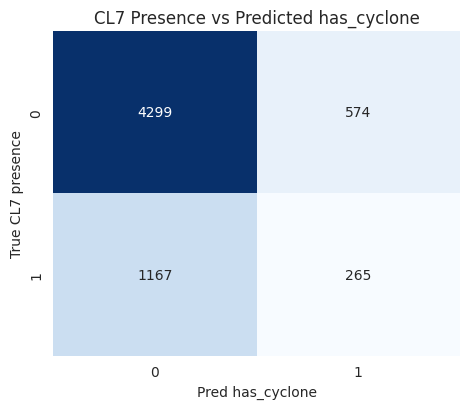

Saved: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/cl7_confusion_matrix.png


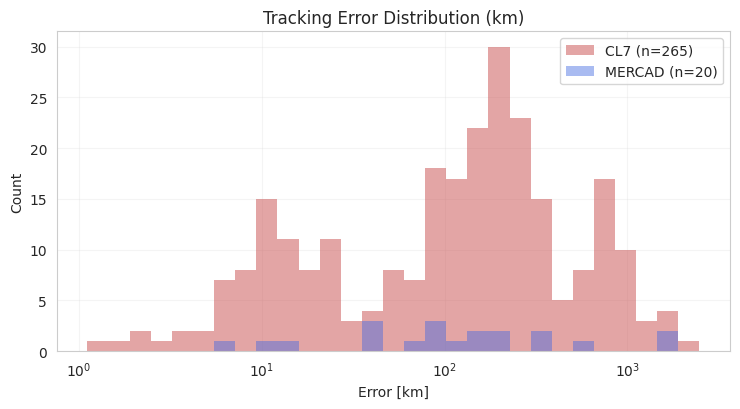

Saved: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/cl7_mercad_error_hist_km.png


In [18]:
# CL7 validation (dry-run, no video)
# Riusa variabili/import globali del notebook: REPO_ROOT, np, pd, plt, sns, normalize_cyclone_id

VIDEOMAE_DIR = REPO_ROOT / 'moduli' / 'videomae'
if str(VIDEOMAE_DIR) not in sys.path:
    sys.path.insert(0, str(VIDEOMAE_DIR))

from track_from_folder import _parse_datetime_series
import engine_for_tracking as tracking_engine

NOTEBOOKS_DIR = REPO_ROOT / 'notebooks'
CL7_PRED_CSV = NOTEBOOKS_DIR / 'tracking_inference_predictions.csv'
CL7_LABELS_CSV = NOTEBOOKS_DIR / 'manos_CL7_pixel.csv'
MERCAD_LABELS_CSV = NOTEBOOKS_DIR / 'mercad_tracks_merged.csv'

CL7_OUT_DIR = NOTEBOOKS_DIR / 'cl7_validation_outputs'
CL7_OUT_DIR.mkdir(parents=True, exist_ok=True)
CL7_JOIN_CSV = CL7_OUT_DIR / 'tracking_inference_predictions_cl7_mercad_validation.csv'
CL7_CM_PNG = CL7_OUT_DIR / 'cl7_confusion_matrix.png'
CL7_HIST_PNG = CL7_OUT_DIR / 'cl7_mercad_error_hist_km.png'

for fp in [CL7_PRED_CSV, CL7_LABELS_CSV, MERCAD_LABELS_CSV]:
    if not fp.exists():
        raise FileNotFoundError(f'File non trovato: {fp}')

print('CL7_PRED_CSV:', CL7_PRED_CSV)
print('CL7_LABELS_CSV:', CL7_LABELS_CSV)
print('MERCAD_LABELS_CSV:', MERCAD_LABELS_CSV)

pred_df = pd.read_csv(CL7_PRED_CSV)
pred_df['datetime'] = _parse_datetime_series(pred_df.get('datetime'))
pred_df['has_cyclone'] = pd.to_numeric(pred_df.get('has_cyclone'), errors='coerce').fillna(0).astype(int)
pred_df['pred_lat'] = pd.to_numeric(pred_df.get('pred_lat'), errors='coerce')
pred_df['pred_lon'] = pd.to_numeric(pred_df.get('pred_lon'), errors='coerce')
pred_df = pred_df[pred_df['datetime'].notna()].copy().sort_values('datetime')

# GT CL7 disponibile ad ora intera: validazione hourly-only.
pred_df = pred_df[
    (pred_df['datetime'].dt.minute == 0)
    & (pred_df['datetime'].dt.second == 0)
    & (pred_df['datetime'].dt.microsecond == 0)
].copy()

cl7_df = pd.read_csv(CL7_LABELS_CSV)
cl7_df['time'] = _parse_datetime_series(cl7_df.get('time'))
cl7_df['lat'] = pd.to_numeric(cl7_df.get('lat'), errors='coerce')
cl7_df['lon'] = pd.to_numeric(cl7_df.get('lon'), errors='coerce')
cl7_df['cyclone_id'] = cl7_df.get('id_cyc_unico').apply(normalize_cyclone_id)
cl7_df = cl7_df[
    cl7_df['time'].notna() & cl7_df['lat'].notna() & cl7_df['lon'].notna() & (cl7_df['cyclone_id'] != '')
].copy().sort_values('time')

mercad_df = pd.read_csv(MERCAD_LABELS_CSV)
mercad_df['time'] = _parse_datetime_series(mercad_df.get('time'))
mercad_df['mercad_lat'] = pd.to_numeric(mercad_df.get('mercad_lat'), errors='coerce')
mercad_df['mercad_lon'] = pd.to_numeric(mercad_df.get('mercad_lon'), errors='coerce')
mercad_df = mercad_df[
    mercad_df['time'].notna() & mercad_df['mercad_lat'].notna() & mercad_df['mercad_lon'].notna()
].copy().sort_values('time')
mercad_df['time_hour'] = mercad_df['time'].dt.round('h')

if pred_df.empty:
    raise RuntimeError('Predizioni hourly vuote.')
if cl7_df.empty:
    raise RuntimeError('CL7 vuoto/non valido.')

overlap_start = max(pred_df['datetime'].min(), cl7_df['time'].min())
overlap_end = min(pred_df['datetime'].max(), cl7_df['time'].max())
if overlap_end < overlap_start:
    raise RuntimeError('Nessuna sovrapposizione temporale tra predictions e CL7.')

pred_eval = pred_df[(pred_df['datetime'] >= overlap_start) & (pred_df['datetime'] <= overlap_end)].copy().sort_values('datetime')
cl7_eval = cl7_df[(cl7_df['time'] >= overlap_start) & (cl7_df['time'] <= overlap_end)].copy()
mercad_eval = mercad_df[(mercad_df['time_hour'] >= overlap_start) & (mercad_df['time_hour'] <= overlap_end)].copy()

# Classification target: presenza CL7 al timestamp.
cl7_presence = cl7_eval.groupby('time').size().rename('cl7_n_points')
pred_eval = pred_eval.merge(cl7_presence, left_on='datetime', right_index=True, how='left')
pred_eval['cl7_n_points'] = pred_eval['cl7_n_points'].fillna(0).astype(int)
pred_eval['y_true_cl7_presence'] = (pred_eval['cl7_n_points'] > 0).astype(int)
pred_eval['y_pred_has_cyclone'] = pred_eval['has_cyclone'].astype(int)

cl7_by_time = {t: g for t, g in cl7_eval.groupby('time')}
mercad_by_time = {t: g for t, g in mercad_eval.groupby('time_hour')}

rows = []
for r in pred_eval.itertuples(index=False):
    dt = pd.Timestamp(r.datetime)
    pred_lat = pd.to_numeric(r.pred_lat, errors='coerce')
    pred_lon = pd.to_numeric(r.pred_lon, errors='coerce')
    has_cyc = int(r.has_cyclone)

    out = {
        'datetime': dt,
        'has_cyclone': has_cyc,
        'pred_lat': pred_lat,
        'pred_lon': pred_lon,
        'y_true_cl7_presence': int(r.y_true_cl7_presence),
        'y_pred_has_cyclone': int(r.y_pred_has_cyclone),
        'cl7_n_points': int(r.cl7_n_points),
        'cl7_match_id': '',
        'cl7_match_lat': np.nan,
        'cl7_match_lon': np.nan,
        'err_km_cl7': np.nan,
        'mercad_n_points': 0,
        'mercad_match_idorig': np.nan,
        'mercad_match_lat': np.nan,
        'mercad_match_lon': np.nan,
        'err_km_mercad': np.nan,
    }

    if has_cyc == 1 and np.isfinite(pred_lat) and np.isfinite(pred_lon):
        g = cl7_by_time.get(dt)
        if g is not None and not g.empty:
            d = tracking_engine._haversine_km(
                np.full(len(g), float(pred_lat)),
                np.full(len(g), float(pred_lon)),
                g['lat'].to_numpy(dtype=float),
                g['lon'].to_numpy(dtype=float),
            )
            i = int(np.argmin(d))
            row_i = g.iloc[i]
            out['cl7_match_id'] = normalize_cyclone_id(row_i.get('id_cyc_unico'))
            out['cl7_match_lat'] = float(row_i['lat'])
            out['cl7_match_lon'] = float(row_i['lon'])
            out['err_km_cl7'] = float(d[i])

        gm = mercad_by_time.get(dt)
        if gm is not None and not gm.empty:
            out['mercad_n_points'] = int(len(gm))
            d2 = tracking_engine._haversine_km(
                np.full(len(gm), float(pred_lat)),
                np.full(len(gm), float(pred_lon)),
                gm['mercad_lat'].to_numpy(dtype=float),
                gm['mercad_lon'].to_numpy(dtype=float),
            )
            j = int(np.argmin(d2))
            row_j = gm.iloc[j]
            out['mercad_match_idorig'] = row_j.get('idorig')
            out['mercad_match_lat'] = float(row_j['mercad_lat'])
            out['mercad_match_lon'] = float(row_j['mercad_lon'])
            out['err_km_mercad'] = float(d2[j])

    rows.append(out)

cl7_val_df = pd.DataFrame(rows).sort_values('datetime').reset_index(drop=True)
cl7_val_df.to_csv(CL7_JOIN_CSV, index=False)
print('Saved:', CL7_JOIN_CSV, '| rows:', len(cl7_val_df))

# --- confusion matrix ---
cm = pd.crosstab(
    cl7_val_df['y_true_cl7_presence'],
    cl7_val_df['y_pred_has_cyclone'],
    rownames=['True CL7 presence'],
    colnames=['Pred has_cyclone'],
    dropna=False,
).reindex(index=[0, 1], columns=[0, 1], fill_value=0)

TN = int(cm.loc[0, 0]); FP = int(cm.loc[0, 1]); FN = int(cm.loc[1, 0]); TP = int(cm.loc[1, 1])
acc = (TP + TN) / max(1, (TP + TN + FP + FN))
prec = TP / max(1, (TP + FP))
rec = TP / max(1, (TP + FN))
f1 = 2 * prec * rec / max(1e-12, (prec + rec))

print(cm)
print(f'Accuracy={acc:.4f} Precision={prec:.4f} Recall={rec:.4f} F1={f1:.4f}')

fig, ax = plt.subplots(figsize=(4.8, 4.2), tight_layout=True)
sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Blues', ax=ax)
ax.set_title('CL7 Presence vs Predicted has_cyclone')
fig.savefig(CL7_CM_PNG, dpi=150)
plt.show()
print('Saved:', CL7_CM_PNG)

# --- error histogram ---
cl7_err = pd.to_numeric(cl7_val_df['err_km_cl7'], errors='coerce').dropna()
cl7_err = cl7_err[cl7_err > 0]
mercad_err = pd.to_numeric(cl7_val_df['err_km_mercad'], errors='coerce').dropna()
mercad_err = mercad_err[mercad_err > 0]

fig, ax = plt.subplots(figsize=(7.5, 4.2), tight_layout=True)
if not cl7_err.empty or not mercad_err.empty:
    vals = []
    if not cl7_err.empty:
        vals.extend(cl7_err.tolist())
    if not mercad_err.empty:
        vals.extend(mercad_err.tolist())
    bins = np.logspace(np.log10(max(1e-3, float(np.min(vals)))), np.log10(float(np.max(vals))), 30)

    if not cl7_err.empty:
        sns.histplot(cl7_err, bins=bins, color='indianred', alpha=0.55, ax=ax, label=f'CL7 (n={len(cl7_err)})')
    if not mercad_err.empty:
        sns.histplot(mercad_err, bins=bins, color='royalblue', alpha=0.45, ax=ax, label=f'MERCAD (n={len(mercad_err)})')

    ax.set_xscale('log')
    ax.set_xlabel('Error [km]')
    ax.set_ylabel('Count')
    ax.set_title('Tracking Error Distribution (km)')
    ax.grid(alpha=0.2)
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No positive errors available', ha='center', va='center')
    ax.set_axis_off()

fig.savefig(CL7_HIST_PNG, dpi=150)
plt.show()
print('Saved:', CL7_HIST_PNG)


In [19]:
# CL7 static maps per-cyclone (periodo overlap con predictions)
# Crea una mappa PNG per ogni id_ciclone CL7 nel periodo, con:
# green=CL7 GT, red=predizioni matchate, blue=MERCAD matchato.
# La linea rossa e' tracciata solo nel window GT; fuori window restano solo i punti.

if '_plot_med_tracks_map' not in globals() or '_infer_gt_interval' not in globals() or '_build_track_title' not in globals():
    raise RuntimeError('Esegui prima la cella di configurazione mappe/helper.')
if 'cl7_val_df' not in globals():
    raise RuntimeError('Esegui prima la cella CL7 validation.')

maps_dir = CL7_OUT_DIR / 'maps_per_cyclone'
maps_dir.mkdir(parents=True, exist_ok=True)

cyclone_ids = sorted([cid for cid in cl7_eval['cyclone_id'].dropna().astype(str).unique() if cid])
print('Cyclones in overlap period:', len(cyclone_ids))

for cid in cyclone_ids:
    gt = cl7_eval[cl7_eval['cyclone_id'] == cid].copy().sort_values('time')
    gt_window = _infer_gt_interval(gt)

    pred_cid = cl7_val_df[
        (cl7_val_df['has_cyclone'] == 1)
        & (cl7_val_df['cl7_match_id'].astype(str) == str(cid))
        & cl7_val_df['pred_lat'].notna()
        & cl7_val_df['pred_lon'].notna()
    ].copy().sort_values('datetime')

    mercad_cid = cl7_val_df[
        (cl7_val_df['has_cyclone'] == 1)
        & (cl7_val_df['cl7_match_id'].astype(str) == str(cid))
        & cl7_val_df['mercad_match_lat'].notna()
        & cl7_val_df['mercad_match_lon'].notna()
    ].copy().sort_values('datetime')

    title = _build_track_title(cid, gt_df=gt)
    out_png = maps_dir / f'cyclone_{cid}.png'
    _plot_med_tracks_map(
        out_png=out_png,
        title=title,
        gt_df=gt.rename(columns={'lat': 'lat', 'lon': 'lon'}),
        pred_df=pred_cid.rename(columns={'datetime': 'time', 'pred_lat': 'lat', 'pred_lon': 'lon'}),
        mercad_df=(
            mercad_cid[['datetime', 'mercad_match_lat', 'mercad_match_lon']].rename(
                columns={'datetime': 'time', 'mercad_match_lat': 'lat', 'mercad_match_lon': 'lon'}
            )
            if not mercad_cid.empty
            else mercad_cid
        ),
        gt_label='CL7 GT',
        pred_label='Prediction',
        mercad_label='MERCAD',
        pred_connect_window=gt_window,
        dpi=140,
    )

print('Saved static maps in:', maps_dir)



Cyclones in overlap period: 29
Saved static maps in: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/maps_per_cyclone


In [ ]:
# CL7 video (opzionale, pesante)
# Tracce aggregate nel tempo: green=CL7, red=predictions, blue=MERCAD

CREATE_CL7_VIDEO = False  # dry-run default
VIDEO_FPS = 10

if not CREATE_CL7_VIDEO:
    print('CREATE_CL7_VIDEO=False -> skip rendering video (dry-run).')
else:
    if 'create_basemap_obj' not in globals():
        from medicane_utils.geo_const import latcorners, loncorners, create_basemap_obj

    frames_dir = CL7_OUT_DIR / 'video_frames'
    video_path = CL7_OUT_DIR / 'cl7_validation_traces.mp4'

    if frames_dir.exists():
        shutil.rmtree(frames_dir)
    frames_dir.mkdir(parents=True, exist_ok=True)

    pred_all = cl7_val_df[
        (cl7_val_df['has_cyclone'] == 1)
        & cl7_val_df['pred_lat'].notna()
        & cl7_val_df['pred_lon'].notna()
    ].copy().sort_values('datetime')

    frame_times = sorted(cl7_val_df['datetime'].dropna().unique())
    for i, dt in enumerate(frame_times):
        fig = plt.figure(figsize=(9, 6), dpi=120)
        ax = fig.add_axes([0.07, 0.08, 0.86, 0.84])
        m = create_basemap_obj(ax=ax)
        m.drawcoastlines(linewidth=0.8, color='black', zorder=2)

        lat_min, lat_max = latcorners
        lon_min, lon_max = loncorners
        parallels = np.arange(lat_min, lat_max + 0.1, 2.0)
        meridians = np.arange(lon_min, lon_max + 0.1, 2.0)
        m.drawparallels(parallels, labels=[1, 0, 0, 0], fontsize=8, color='0.5')
        m.drawmeridians(meridians, labels=[0, 0, 0, 1], fontsize=8, color='0.5', rotation=45)

        cl7_upto = cl7_eval[cl7_eval['time'] <= dt]
        pred_upto = pred_all[pred_all['datetime'] <= dt]
        mercad_upto = cl7_val_df[
            (cl7_val_df['datetime'] <= dt)
            & cl7_val_df['mercad_match_lat'].notna()
            & cl7_val_df['mercad_match_lon'].notna()
        ]

        if not cl7_upto.empty:
            xg, yg = m(cl7_upto['lon'].to_numpy(), cl7_upto['lat'].to_numpy())
            m.plot(xg, yg, color='green', linewidth=1.2, alpha=0.75)
            cl7_now = cl7_eval[cl7_eval['time'] == dt]
            if not cl7_now.empty:
                xg0, yg0 = m(cl7_now['lon'].to_numpy(), cl7_now['lat'].to_numpy())
                m.scatter(xg0, yg0, c='green', s=14, marker='o', zorder=5, label='CL7 GT')

        if not pred_upto.empty:
            xr, yr = m(pred_upto['pred_lon'].to_numpy(), pred_upto['pred_lat'].to_numpy())
            m.plot(xr, yr, color='red', linewidth=1.2, alpha=0.8)
            pred_now = pred_all[pred_all['datetime'] == dt]
            if not pred_now.empty:
                xr0, yr0 = m(pred_now['pred_lon'].to_numpy(), pred_now['pred_lat'].to_numpy())
                m.scatter(xr0, yr0, c='red', s=14, marker='o', zorder=6, label='Prediction')

        if not mercad_upto.empty:
            xb, yb = m(mercad_upto['mercad_match_lon'].to_numpy(), mercad_upto['mercad_match_lat'].to_numpy())
            m.plot(xb, yb, color='royalblue', linewidth=1.2, alpha=0.75)
            mercad_now = mercad_upto[mercad_upto['datetime'] == dt]
            if not mercad_now.empty:
                xb0, yb0 = m(mercad_now['mercad_match_lon'].to_numpy(), mercad_now['mercad_match_lat'].to_numpy())
                m.scatter(xb0, yb0, c='royalblue', s=14, marker='o', zorder=7, label='MERCAD')

        ax.set_title(f'CL7 validation tracks | {pd.Timestamp(dt).strftime("%Y-%m-%d %H:%M")}')
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            uniq = {}
            for h, l in zip(handles, labels):
                if l not in uniq:
                    uniq[l] = h
            ax.legend(uniq.values(), uniq.keys(), loc='lower left', fontsize=8)

        fig.savefig(frames_dir / f'frame_{i:05d}.png', dpi=120)
        plt.close(fig)

    ffmpeg = shutil.which('ffmpeg')
    if ffmpeg is None:
        print('[WARN] ffmpeg non trovato: video non creato.')
    else:
        cmd = [
            ffmpeg,
            '-y',
            '-framerate', str(int(VIDEO_FPS)),
            '-i', str(frames_dir / 'frame_%05d.png'),
            '-c:v', 'libx264',
            '-crf', '18',
            '-preset', 'medium',
            '-pix_fmt', 'yuv420p',
            str(video_path),
        ]
        subprocess.run(cmd, check=True)
        print('Saved video:', video_path)
